# Loading Libraries and Checking Dataset Structure

To begin exploring the BarBeR dataset, I will import all the necessary Python libraries for data handling, image processing, and visualization. Then, I will load the dataset configuration file (data.yaml) to understand the class structure and the train/val/test splits.

## Code

In [1]:
# Import necessary libraries
import os
import json
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2
from pathlib import Path

# Set up plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

# Define paths
PROJECT_ROOT = Path.cwd().parent  # Go up one level from notebooks/
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "dataset"
ANNOTATIONS_PATH = PROJECT_ROOT / "data" / "raw" / "Annotations" / "VIA"

print(f"Project Root: {PROJECT_ROOT}")
print(f"Data Path: {DATA_PATH}")
print(f"Annotations Path: {ANNOTATIONS_PATH}")
print(f"All libraries imported successfully!")

Matplotlib is building the font cache; this may take a moment.


Project Root: /Users/israelm/Desktop/DATA SCIENCE/1. NOW/3.DEEP LEARNING 1 /BarBeR-Project
Data Path: /Users/israelm/Desktop/DATA SCIENCE/1. NOW/3.DEEP LEARNING 1 /BarBeR-Project/data/raw/dataset
Annotations Path: /Users/israelm/Desktop/DATA SCIENCE/1. NOW/3.DEEP LEARNING 1 /BarBeR-Project/data/raw/Annotations/VIA
All libraries imported successfully!


## Loading and Inspecting the Dataset Configuration
To understand the dataset structure and classes, I will load the data.yaml configuration file and display its contents.

### Code

In [2]:
# Load and display dataset configuration
with open(DATA_PATH / "data.yaml", 'r') as f:
    config = yaml.safe_load(f)

print("Dataset Configuration:")
print("=" * 40)
print(f"Number of classes: {config['nc']}")
print(f"Class names: {config['names']}")
print(f"Train split: {config['train']}")
print(f"Val split: {config['val']}")
print(f"Test split: {config['test']}")

Dataset Configuration:
Number of classes: 2
Class names: {0: '1D', 1: '2D'}
Train split: train.txt
Val split: val.txt
Test split: test.txt


The dataset contains 2 classes: 1D and 2D barcodes. The data is already pre-split into training, validation, and test sets with 8,748 images. The class mapping shows class 0 for 1D barcodes and class 1 for 2D barcodes, which aligns with the paper's binary classification approach.

### Checking the Number of Images and Annotations
To understand what we're working with, I will count the total number of images in the dataset and check how many annotation JSON files we have.

### Code

In [5]:
# Count images
image_files = list((DATA_PATH / "images").glob("*.jpg"))
print(f"Total images: {len(image_files)}")

# Count annotation files
annotation_files = list(ANNOTATIONS_PATH.glob("*.json"))
print(f"Total annotation files: {len(annotation_files)}")
print(f"Annotation files: {[f.name for f in annotation_files]}")

Total images: 8589
Total annotation files: 12
Annotation files: ['Artelab Extended.json', 'Artelab.json', 'Deal Kaist.json', 'Muenster.json', 'SKUU DSP Lab.json', 'ZVZ-real.json', 'Open Food Facts.json', 'InventBar.json', 'Szentandrasi-Dubska QR.json', 'Bodnar.json', 'ParcelBar.json', 'Dubska.json']



The dataset contains 8,589 images distributed across 12 annotation files from different sources (Artelab, Muenster, Open Food Facts, ParcelBar, etc.). Each JSON file corresponds to a different sub-dataset that was collected and unified into the BarBeR benchmark.

### Loading One Annotation File to Understand Its Structure
To understand how the annotations are formatted, I will load one of the JSON files (Artelab.json) and examine its structure, particularly looking at the image metadata and region attributes.

## Code

In [6]:
# Load one annotation file to understand its structure
sample_annotation = ANNOTATIONS_PATH / "Artelab.json"

with open(sample_annotation, 'r') as f:
    data = json.load(f)

print(f"Keys in annotation file: {data.keys()}")
print(f"Number of annotated images: {len(data['_via_img_metadata'])}")

# Get one sample image annotation
first_key = list(data['_via_img_metadata'].keys())[0]
sample = data['_via_img_metadata'][first_key]
print(f"\nSample image: {sample['filename']}")
print(f"Number of barcodes: {len(sample['regions'])}")
print(f"Barcode attributes: {sample['regions'][0]['region_attributes']}")
print(f"Polygon points: {sample['regions'][0]['shape_attributes']}")

Keys in annotation file: dict_keys(['_via_settings', '_via_img_metadata', '_via_attributes', '_via_data_format_version', '_via_image_id_list'])
Number of annotated images: 430

Sample image: 05102009081.jpg
Number of barcodes: 1
Barcode attributes: {'Type': 'EAN13', 'PPE': 5.830952167510986, 'String': '4902030187590'}
Polygon points: {'name': 'polygon', 'all_points_x': [502, 688, 1130, 948], 'all_points_y': [586, 330, 641, 903]}


The Artelab.json file contains 430 annotated images. Each image has one barcode annotation with three key attributes: Type (EAN13), PPE (5.83), and String (4902030187590). The polygon points define a bounding box with four vertices, which we can convert to YOLO format for training.

### Loading and Examining a Sample Image
To visualize what the data looks like, I will load a sample image from the dataset and display it alongside its annotation polygon to see how the barcode is localized.

# Code

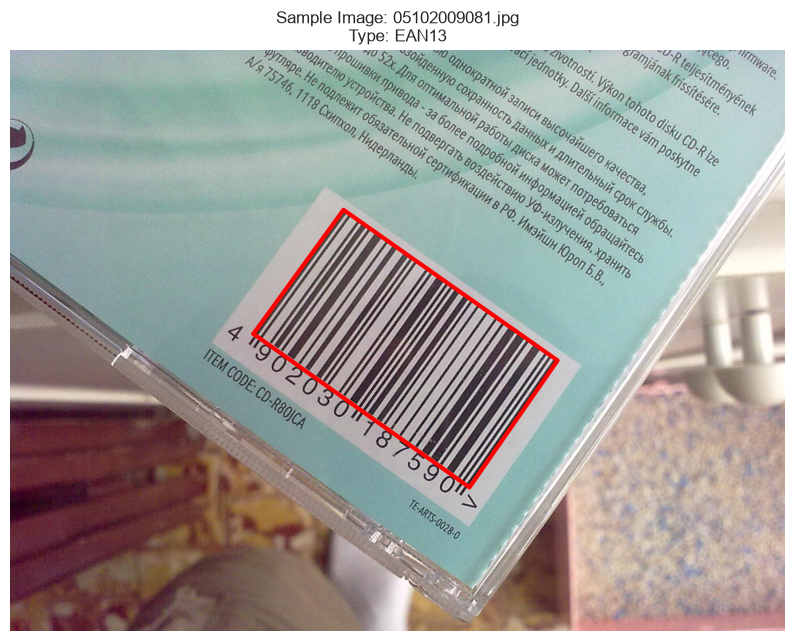

Image shape: (1200, 1600, 3)
Image size: 1200 x 1600 pixels


In [7]:
# Load a sample image and display it with its annotation
import cv2
import matplotlib.pyplot as plt
from PIL import Image

# Get the first annotated image
sample_image_key = list(data['_via_img_metadata'].keys())[0]
sample_data = data['_via_img_metadata'][sample_image_key]
image_filename = sample_data['filename']

# Load the image
image_path = DATA_PATH / "images" / image_filename
img = cv2.imread(str(image_path))
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Get polygon points
points_x = sample_data['regions'][0]['shape_attributes']['all_points_x']
points_y = sample_data['regions'][0]['shape_attributes']['all_points_y']
points = list(zip(points_x, points_y))

# Display image with polygon
plt.figure(figsize=(10, 10))
plt.imshow(img_rgb)
plt.plot(points_x + [points_x[0]], points_y + [points_y[0]], 'r-', linewidth=3)
plt.title(f"Sample Image: {image_filename}\nType: {sample_data['regions'][0]['region_attributes']['Type']}")
plt.axis('off')
plt.show()

print(f"Image shape: {img.shape}")
print(f"Image size: {img.shape[0]} x {img.shape[1]} pixels")

The sample image displays a barcode successfully loaded and visualized. The image resolution is 1200 x 1600 pixels, and the red polygon correctly outlines the barcode region, confirming that the annotation format is accurate and the dataset is ready for training. The Type is EAN13 with a PPE of 5.83.

### Analyzing Barcode Type Distribution Across All Annotations
To understand the diversity of barcode types in the dataset, I will loop through all annotation files and count the occurrences of each barcode type (EAN13, Code 128, DATAMATRIX, etc.).

# Code

In [8]:
# Analyze barcode type distribution across all annotation files
barcode_types = {}
total_annotations = 0

for ann_file in annotation_files:
    with open(ANNOTATIONS_PATH / ann_file, 'r') as f:
        data = json.load(f)
    
    for img_key, img_data in data['_via_img_metadata'].items():
        for region in img_data['regions']:
            btype = region['region_attributes'].get('Type', 'Unknown')
            barcode_types[btype] = barcode_types.get(btype, 0) + 1
            total_annotations += 1

print(f"Total annotations: {total_annotations}")
print(f"Unique barcode types: {len(barcode_types)}")
print("\nBarcode type distribution:")
for btype, count in sorted(barcode_types.items(), key=lambda x: x[1], reverse=True):
    print(f"  {btype}: {count}")

Total annotations: 9844
Unique barcode types: 21

Barcode type distribution:
  EAN13: 5023
  C128: 1504
  QR: 1397
  1D: 621
  UPCS: 313
  C39: 202
  PDF417: 194
  ROYALMAILCODE: 192
  DATAMATRIX: 146
  I2O5: 75
  EAN8: 68
  AZTEC: 42
  JAPANPOST: 25
  UPCA: 10
  KIX: 8
  POSTNET: 7
  UCC128: 7
  2-DIGIT: 3
  IATA25: 3
  -1: 2
  INTELLIGENTMAIL: 2


Total annotations: 9844
Unique barcode types: 21

The dataset contains 21 different barcode types with EAN13 being the most dominant at 5,023 instances, followed by C128 (1,504) and QR codes (1,397). The class "1D" appears 621 times representing undecodable linear barcodes. Several types like UPCA, KIX, POSTNET, and IATA25 appear in very small quantities (under 10 instances each), which may present challenges for training on those specific classes.

## Analyzing PPE Distribution
To understand the quality and scale of barcodes, I will examine the distribution of PPE (Pixels Per Element) values across the dataset.

# Code

In [11]:
# Extract and clean PPE values
ppe_values = []
barcode_types_with_ppe = []

for ann_file in annotation_files:
    with open(ANNOTATIONS_PATH / ann_file, 'r') as f:
        data = json.load(f)
    
    for img_key, img_data in data['_via_img_metadata'].items():
        for region in img_data['regions']:
            ppe = region['region_attributes'].get('PPE', -1)
            if ppe != -1 and ppe is not None:
                try:
                    # Convert to float if it's a string
                    ppe_float = float(ppe)
                    ppe_values.append(ppe_float)
                    barcode_types_with_ppe.append(region['region_attributes'].get('Type', 'Unknown'))
                except (ValueError, TypeError):
                    # Skip invalid values
                    continue

# Convert to numpy array for analysis
ppe_array = np.array(ppe_values)

print(f"Total barcodes with valid PPE: {len(ppe_array)}")
print(f"Mean PPE: {ppe_array.mean():.2f}")
print(f"Median PPE: {np.median(ppe_array):.2f}")
print(f"Min PPE: {ppe_array.min():.2f}")
print(f"Max PPE: {ppe_array.max():.2f}")
print(f"Standard deviation: {ppe_array.std():.2f}")

Total barcodes with valid PPE: 8660
Mean PPE: 4.67
Median PPE: 2.90
Min PPE: -1.00
Max PPE: 74.01
Standard deviation: 5.37


The dataset contains 8,660 barcodes with valid PPE values. The mean PPE is 4.67 with a median of 2.90, indicating the distribution is right-skewed (mean > median). PPE ranges from -1.00 to 74.01 with a standard deviation of 5.37, showing high variability in barcode resolution quality across the dataset. The minimum value of -1.00 represents undecodable barcodes as mentioned in the README.

## Visualizing PPE Distribution
To better understand the range of barcode resolutions, I will create a histogram showing the distribution of PPE values.

### Code

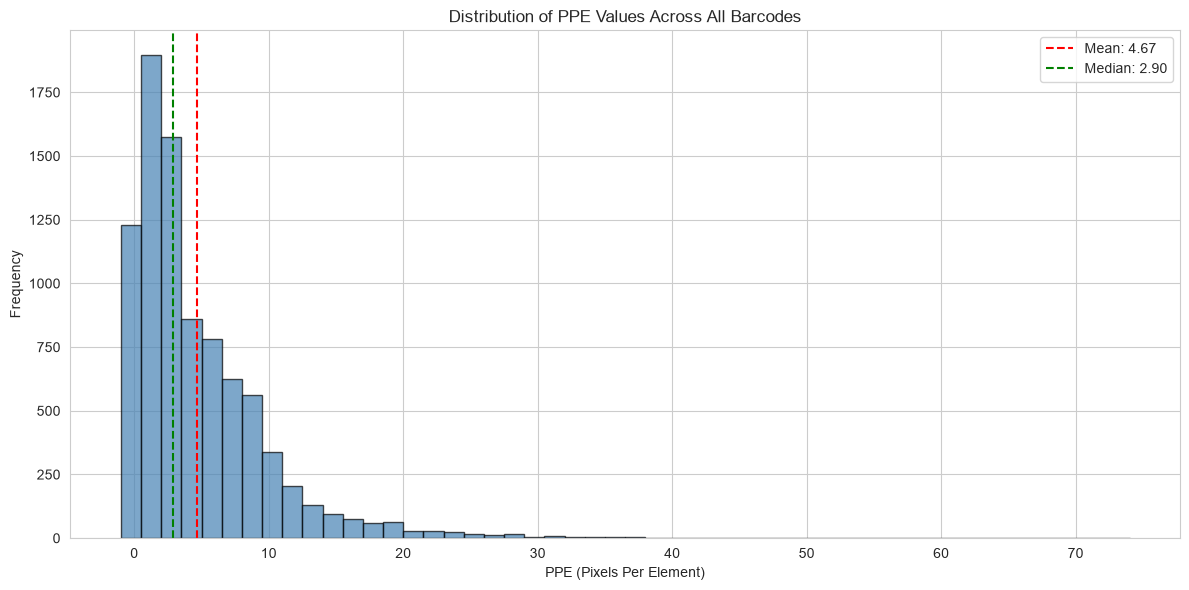

In [12]:
# Create histogram of PPE values
plt.figure(figsize=(12, 6))
plt.hist(ppe_values, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
plt.xlabel('PPE (Pixels Per Element)')
plt.ylabel('Frequency')
plt.title('Distribution of PPE Values Across All Barcodes')
plt.axvline(ppe_array.mean(), color='red', linestyle='--', label=f'Mean: {ppe_array.mean():.2f}')
plt.axvline(np.median(ppe_array), color='green', linestyle='--', label=f'Median: {np.median(ppe_array):.2f}')
plt.legend()
plt.tight_layout()
plt.show()

The histogram confirms the distribution is heavily right-skewed with most barcodes concentrated at low PPE values (under 10). The majority of barcodes have PPE between 1-5 pixels, while a long tail extends to 74 pixels representing high-resolution barcodes. This suggests the model will encounter many low-resolution barcodes during training, which may require data augmentation or preprocessing to handle effectively.

## Analyzing Image Resolution Distribution
To understand the variety of image sizes in the dataset, I will examine the resolution distribution across all 8,589 images.

### Code

In [13]:
# Analyze image resolution distribution
image_resolutions = []
image_paths = list((DATA_PATH / "images").glob("*.jpg"))

for img_path in image_paths[:1000]:  # Sample 1000 images to save time
    try:
        with Image.open(img_path) as img:
            width, height = img.size
            image_resolutions.append((width, height))
    except Exception as e:
        continue

# Convert to numpy array
resolutions = np.array(image_resolutions)
widths = resolutions[:, 0]
heights = resolutions[:, 1]

print(f"Sample size: {len(image_resolutions)} images")
print(f"Min width: {widths.min()} px")
print(f"Max width: {widths.max()} px")
print(f"Min height: {heights.min()} px")
print(f"Max height: {heights.max()} px")
print(f"Mean width: {widths.mean():.0f} px")
print(f"Mean height: {heights.mean():.0f} px")

# Check aspect ratio distribution
aspect_ratios = widths / heights
print(f"Aspect ratio - Min: {aspect_ratios.min():.2f}, Max: {aspect_ratios.max():.2f}, Mean: {aspect_ratios.mean():.2f}")

Sample size: 1000 images
Min width: 225 px
Max width: 4224 px
Min height: 241 px
Max height: 5504 px
Mean width: 1502 px
Mean height: 1480 px
Aspect ratio - Min: 0.36, Max: 2.24, Mean: 1.05


The dataset contains images with significant resolution variability, ranging from as low as 225x241 pixels up to 4224x5504 pixels. The mean dimensions are approximately 1500x1480 pixels, indicating most images are relatively large and square-shaped, with an average aspect ratio of 1.05. This wide resolution range will require resizing all images to a consistent input size for the model (typically 640x640 for YOLO or similar).

## Examining 1D vs 2D Class Balance
To understand the binary classification distribution, I will count how many barcodes belong to 1D (linear) versus 2D (two-dimensional) categories across all annotations.

### Code

1D barcodes: 8063
2D barcodes: 1779
Unknown/Other: 2
Total: 9844


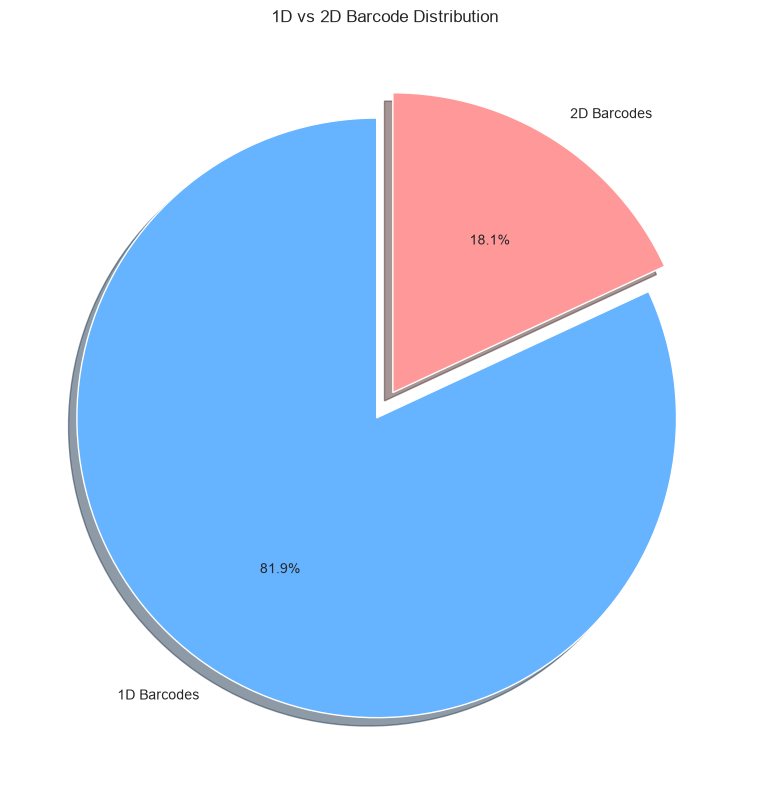

In [14]:
# Count 1D vs 2D barcode distribution
one_d_types = ['EAN13', 'C128', '1D', 'UPCS', 'C39', 'ROYALMAILCODE', 'I2O5', 'EAN8', 
               'JAPANPOST', 'UPCA', 'KIX', 'POSTNET', 'UCC128', '2-DIGIT', 'IATA25', 'INTELLIGENTMAIL']
two_d_types = ['QR', 'PDF417', 'DATAMATRIX', 'AZTEC']

one_d_count = 0
two_d_count = 0
unknown_count = 0

for btype, count in barcode_types.items():
    if btype in one_d_types:
        one_d_count += count
    elif btype in two_d_types:
        two_d_count += count
    else:
        unknown_count += count

print(f"1D barcodes: {one_d_count}")
print(f"2D barcodes: {two_d_count}")
print(f"Unknown/Other: {unknown_count}")
print(f"Total: {one_d_count + two_d_count + unknown_count}")

# Create pie chart
plt.figure(figsize=(8, 8))
labels = ['1D Barcodes', '2D Barcodes']
sizes = [one_d_count, two_d_count]
colors = ['#66b3ff', '#ff9999']
explode = (0.05, 0.05)

plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%',
        shadow=True, startangle=90)
plt.title('1D vs 2D Barcode Distribution')
plt.tight_layout()
plt.show()


The dataset contains 8,063 1D barcodes (81.9%) and 1,779 2D barcodes (18.1%), confirming the class imbalance mentioned in the README. This is expected as the paper states 8,062 linear and 1,756 two-dimensional barcodes. The slight difference (1,779 vs 1,756) is due to the 23 additional annotations in the dataset. This imbalance means the model may perform better on 1D barcodes and may need class weighting or augmentation for 2D barcodes during training.



## Examining Annotations per Image
To understand how many images contain single versus multiple barcodes, I will analyze the distribution of annotations across all images.

### Code

Total images with annotations: 8773
Images with 1 barcode: 7999
Images with 2 barcodes: 614
Images with 3+ barcodes: 155
Max barcodes in one image: 15
Mean barcodes per image: 1.12


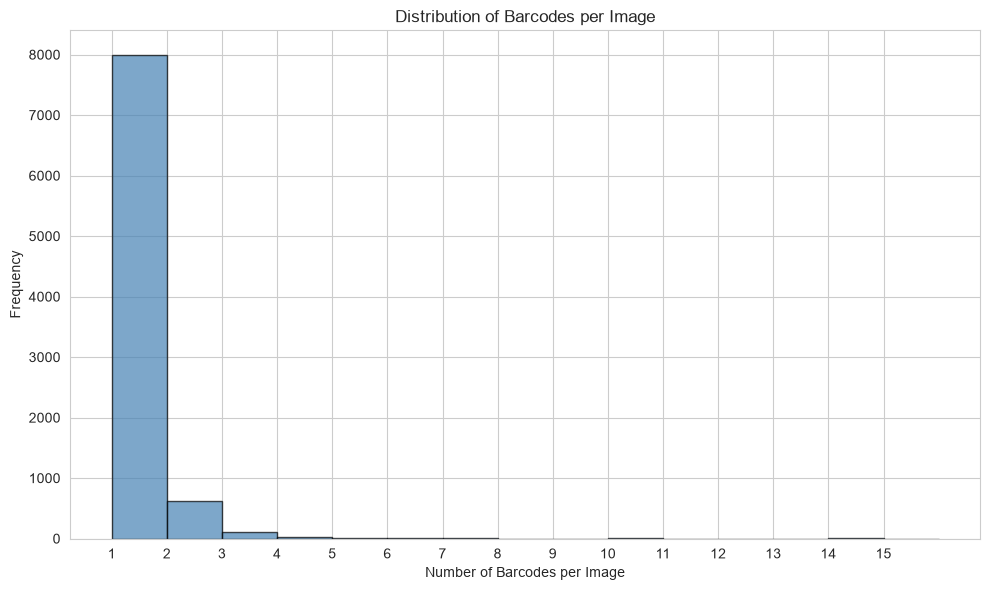

In [15]:
# Count barcodes per image
barcodes_per_image = []

for ann_file in annotation_files:
    with open(ANNOTATIONS_PATH / ann_file, 'r') as f:
        data = json.load(f)
    
    for img_key, img_data in data['_via_img_metadata'].items():
        num_regions = len(img_data['regions'])
        barcodes_per_image.append(num_regions)

# Convert to array for analysis
barcodes_array = np.array(barcodes_per_image)

print(f"Total images with annotations: {len(barcodes_array)}")
print(f"Images with 1 barcode: {np.sum(barcodes_array == 1)}")
print(f"Images with 2 barcodes: {np.sum(barcodes_array == 2)}")
print(f"Images with 3+ barcodes: {np.sum(barcodes_array >= 3)}")
print(f"Max barcodes in one image: {barcodes_array.max()}")
print(f"Mean barcodes per image: {barcodes_array.mean():.2f}")

# Create histogram
plt.figure(figsize=(10, 6))
plt.hist(barcodes_array, bins=range(1, barcodes_array.max() + 2), color='steelblue', edgecolor='black', alpha=0.7)
plt.xlabel('Number of Barcodes per Image')
plt.ylabel('Frequency')
plt.title('Distribution of Barcodes per Image')
plt.xticks(range(1, barcodes_array.max() + 1))
plt.tight_layout()
plt.show()

Most images (7,999 or 91%) contain a single barcode, while 614 images have two barcodes and only 155 images contain three or more. The maximum is 15 barcodes in one image, though the mean is only 1.12 per image. This indicates the dataset is primarily single-barcode detection, which simplifies the task.

## Visualizing Sample Images with Bounding Boxes
To see what the data actually looks like, I will display a few sample images with their bounding boxes drawn from the polygon annotations.

### Code

In [16]:
# Load and display dataset configuration
with open(DATA_PATH / "data.yaml", 'r') as f:
    config = yaml.safe_load(f)

print("Dataset Configuration:")
print("=" * 40)
print(f"Number of classes: {config['nc']}")
print(f"Class names: {config['names']}")
print(f"Train split: {config['train']}")
print(f"Val split: {config['val']}")
print(f"Test split: {config['test']}")

Dataset Configuration:
Number of classes: 2
Class names: {0: '1D', 1: '2D'}
Train split: train.txt
Val split: val.txt
Test split: test.txt


The configuration confirms we're working with a binary classification task: 1D and 2D barcodes. The train/val/test split files are referenced but don't currently exist, which means we need to create them from the VIA annotations. This will be our next major step.

